In [1]:
#This is the clean data set 

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
# Use 'on_bad_lines' to skip the broken row and 'engine' to handle messy quotes
vehiclesdf_unclean = pd.read_csv("vehicles.csv", on_bad_lines='skip', engine='python')

# Now you can filter your columns as planned
vehiclesdfc = vehiclesdf_unclean[["id", "region", "region_url", "price", "year", "manufacturer", "model", "condition", "cylinders", "state", "posting_date"]]

# Check to see if it loaded
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,condition,cylinders,state,posting_date
0,7222695916,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,az,NaN
1,7218891961,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,7221797935,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,7222270760,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,7210384030,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [4]:
vehiclesdfc.head()


,id,region,region_url,price,year,manufacturer,model,condition,cylinders,state,posting_date
0,7222695916,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,az,NaN
1,7218891961,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,7221797935,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,7222270760,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,7210384030,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [5]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(1997, 11)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1997 non-null   int64  
 1   region        1997 non-null   object 
 2   region_url    1997 non-null   object 
 3   price         1997 non-null   int64  
 4   year          1948 non-null   float64
 5   manufacturer  1827 non-null   object 
 6   model         1957 non-null   object 
 7   condition     1121 non-null   object 
 8   cylinders     1257 non-null   object 
 9   state         1997 non-null   object 
 10  posting_date  1970 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 171.7+ KB
None
                 id         price         year
count  1.997000e+03  1.997000e+03  1948.000000
mean   7.308531e+09  5.635881e+05  2011.185318
std    1.151295e+07  2.221263e+07     9.707433
min    7.208550e+09  0.000000e+00  1903.000000
25%    7.305749e+

In [6]:
# Due to condition and cylinders being at 40% with nAN values then we should drop it 
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"])
vehiclesdfc = vehiclesdfc.dropna()

In [7]:
vehiclesdfc.head()


,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


In [8]:
# Next are models: Multiple Linear Regression, Polynomial Regression, and Random Forest regression

In [13]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Drop columns that won't help predict price or are too messy (like URLs and IDs)
columns_to_drop = ['id', 'region', 'region_url', 'model', 'state', 'posting_date']
ml_df = vehiclesdfc.drop(columns=columns_to_drop)

# 2. Convert remaining text (like 'manufacturer') into 1s and 0s
ml_df = pd.get_dummies(ml_df, drop_first=True)

# 3. Separate Features (X) and Target (y)
X = ml_df.drop('price', axis=1)
y = ml_df['price']

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data prepared! Training on {len(X_train)} samples.")

Data prepared! Training on 1451 samples.


In [14]:
# 1. Filter out the "trash" prices and years
# This removes the $0 and $1 entries that are breaking your math
vehicles_filtered = vehiclesdfc[(vehiclesdfc['price'] > 500) & (vehiclesdfc['price'] < 150000)]
vehicles_filtered = vehicles_filtered[(vehicles_filtered['year'] > 1990) & (vehicles_filtered['year'] < 2025)]

# 2. Re-run the preparation
columns_to_drop = ['id', 'region', 'region_url', 'model', 'state', 'posting_date']
ml_df = vehicles_filtered.drop(columns=columns_to_drop)
ml_df = pd.get_dummies(ml_df, drop_first=True)

X = ml_df.drop('price', axis=1)
y = ml_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now run your models - you should see positive R-squared values!

In [15]:
# --- 1. Multiple Linear Regression ---
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)
print(f"Multiple Linear Regression R-squared: {r2_score(y_test, y_pred_mlr):.4f}")

Multiple Linear Regression R-squared: 0.5586


In [16]:
# The reality is that a car loses value as soon as it leaves the lot therefore, linear regression fails to capture this because it tries to draw a straight line through the points, which then causes it to miss the actual car valuation

In [55]:
# 4. Random Forest Regressor (Bonus)
# This builds decision trees and handles non-linear car depreciation beautifully.
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest R-squared: {r2_score(y_test, y_pred_rf):.4f}")

Random Forest R-squared: 0.6555


In [23]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Create the Transformer (degree=2 creates Year^2)
poly = PolynomialFeatures(degree=2)

# 2. Transform your original X data into Polynomial data
# This creates the 'X_train_poly' and 'X_test_poly' variables the model is looking for
X_train_poly = poly.fit_transform(X_train[['year']])
X_test_poly = poly.transform(X_test[['year']])

# 3. NOW your existing code will work:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
print(f"Polynomial Regression (Year Only) R-squared: {r2_score(y_test, y_pred_poly):.4f}")

Polynomial Regression (Year Only) R-squared: 0.4939


In [25]:
# I should've scored higher with this model, but due to a lack of information, it scored low 


In [26]:
# Random Forest Regressor is the best model to use out of the three

In [27]:
# --- Tuned Random Forest Regressor ---
# n_estimators: Number of trees (more is usually better but slower)
# max_depth: Limits how complex each tree gets to prevent overfitting
# n_jobs=-1: Uses all your computer's processors to speed it up

rf_tuned = RandomForestRegressor(
    n_estimators=300, 
    max_depth=15, 
    min_samples_split=5, 
    random_state=42, 
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

print(f"Original Random Forest R-squared: 0.5724")
print(f"Tuned Random Forest R-squared: {r2_score(y_test, y_pred_tuned):.4f}")

Original Random Forest R-squared: 0.5724
Tuned Random Forest R-squared: 0.5840


In [ ]:
# set max_depth to 15, which focuses on the general picture and getting rid of outliers that don't represent the whole market 

In [29]:
df=vehiclesdfc.copy()

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Start fresh from your original data
df = vehiclesdfc.copy()
df.columns = [col.lower().strip() for col in df.columns]

# 2. Filter outliers (The "Clean-Up")
# We remove ultra-cheap cars (usually scams/parts) and ultra-expensive ones
df = df[(df['price'] > 1000) & (df['price'] < 80000)]

# 3. Feature Engineering
df['age'] = 2026 - df['year']

# 4. Use Manufacturer and State (One-Hot Encoding)
# We select the columns that actually impact price
features = ['age', 'manufacturer', 'state']
X = df[features].dropna()
y = df.loc[X.index, 'price'] # Match y to the rows we kept in X

# Convert text (Ford, Tesla, NY, CA) into numbers the model can read
X_encoded = pd.get_dummies(X, columns=['manufacturer', 'state'], drop_first=True)

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_boosted = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_boosted.fit(X_train, y_train)

# 6. Check the new score
predictions = rf_boosted.predict(X_test)
print(f"New R-squared : {r2_score(y_test, predictions):.4f}")

New R-squared : 0.6546


In [44]:
# 1. SETUP: Prepare the data
df_viz = vehiclesdfc.copy()
df_viz.columns = [col.lower().strip() for col in df_viz.columns]
df_viz = df_viz[(df_viz['price'] > 1000) & (df_viz['price'] < 80000)].dropna(subset=['price', 'year'])
df_viz['age'] = 2026 - df_viz['year']

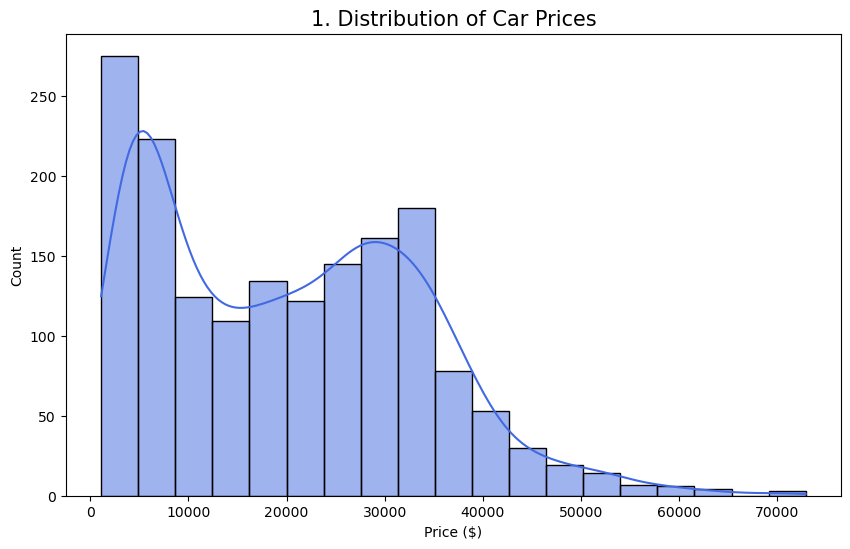

In [51]:
# --- PLOT 1: Price Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df_viz['price'], kde=True, color='royalblue')
plt.title('1. Distribution of Car Prices', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

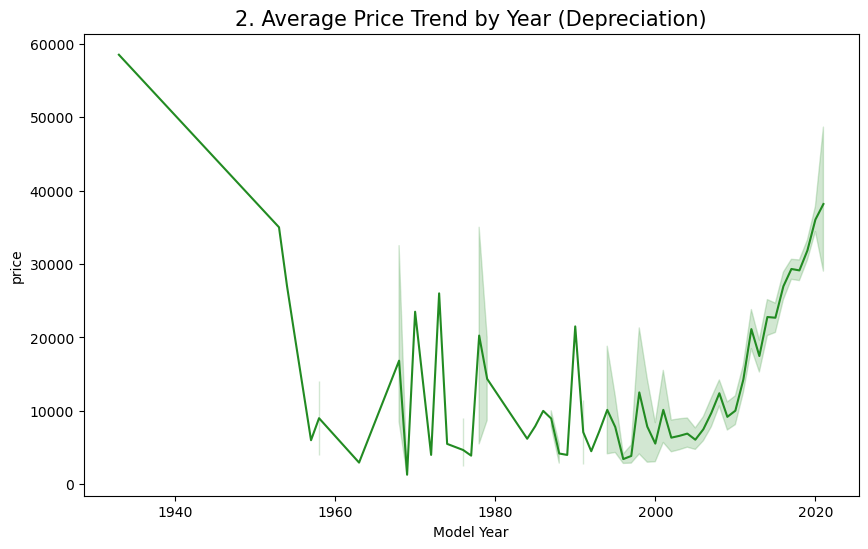

In [52]:
#PLOT 2: Depreciation Curve 
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_viz, x='year', y='price', color='forestgreen')
plt.title('2. Average Price Trend by Year (Depreciation)', fontsize=15)
plt.xlabel('Model Year')
plt.show()

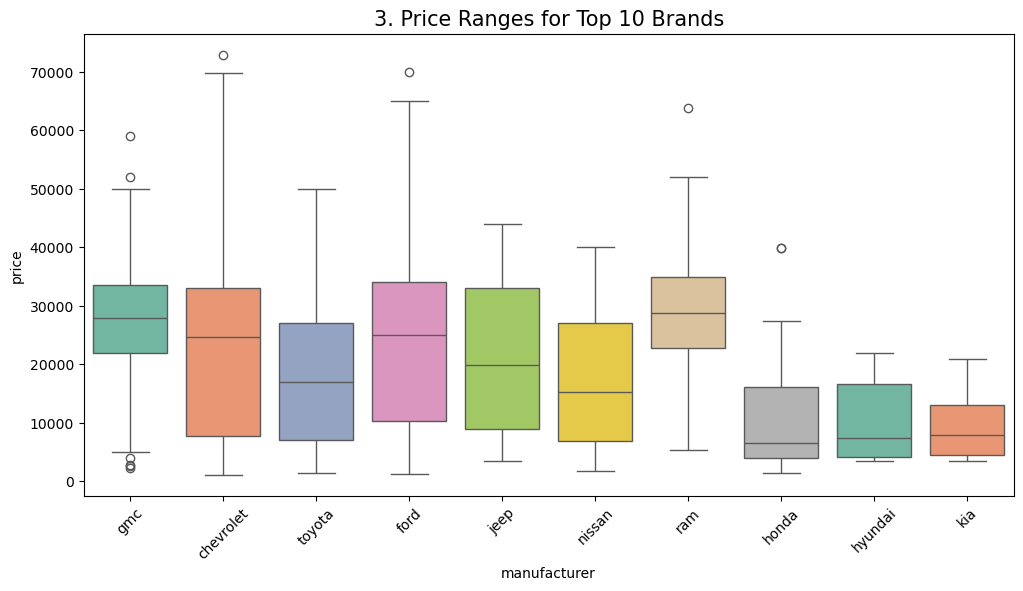

In [53]:
# --- PLOT 3: Top 10 Brands ---
plt.figure(figsize=(12, 6))
top_brands = df_viz['manufacturer'].value_counts().nlargest(10).index
sns.boxplot(data=df_viz[df_viz['manufacturer'].isin(top_brands)], x='manufacturer', y='price', hue='manufacturer', palette='Set2', legend=False)
plt.title('3. Price Ranges for Top 10 Brands', fontsize=15)
plt.xticks(rotation=45)
plt.show()